## Animations of distant retrograde orbits

with ffmpeg

- an animation in HEE coordinates for Figure 2 in the paper Möstl et al. 2026b in prep is produced (with 9 spacecraft), then some more similar ones with different numbers of spacecraft
- a movie in an HCI inertial system is also produced for better visualisation for talks 

### Ideas

- make movies with black background



In [17]:
import time
import os
import requests
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
from matplotlib.patches import Rectangle

import pickle
import spiceypy
import pandas as pd
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy import stats
from scipy.signal import argrelextrema
import multiprocessing as mp

import astropy.units as u
from astropy import constants as const

au=const.au.value*1e-3
M_sun = const.M_sun.value  # Sun mass
M_earth = const.M_earth.value   # Earth mass
G=const.G.value*1e-9 # use km
# Sun-Earth system parameters mu: mass parameter (m2/(m1+m2))
mu = M_earth/(M_sun+M_earth)  # Earth mass / (Sun + Earth mass)

# Calculate system parameters
M_total = M_sun + M_earth
omega = np.sqrt(G * M_total / au**3)  # Angular velocity of rotating frame (rad/s) from keplers laws?
T=2*np.pi/omega/86400 #year in decimal days

print('Au in km:',au) # in km
print('M sun',M_sun)
print('M earth',M_earth)
print('G:',G)

print(f"System Parameters:")
print(f"  Mass parameter μ = {mu:.6e}")
print(f"  Earth-Sun distance au = {au:.6e} km")
print(f"  Angular velocity ω = {omega:.6e} rad/s")
print(f"  Orbital period = {2*np.pi/omega/86400:.2f} days\n")

kernels_path='kernels'

#make sure to convert the current notebook to a script if you want to run it on a server
os.system('jupyter nbconvert --to script animations.ipynb')   


Au in km: 149597870.70000002
M sun 1.988409870698051e+30
M earth 5.972167867791379e+24
G: 6.6743e-20
System Parameters:
  Mass parameter μ = 3.003480e-06
  Earth-Sun distance au = 1.495979e+08 km
  Angular velocity ω = 1.990987e-07 rad/s
  Orbital period = 365.26 days



[NbConvertApp] Converting notebook animations.ipynb to script
[NbConvertApp] Writing 21663 bytes to animations.py


0

### load planetary orbits
get planetary orbits from spiceypy with files    
load de442.bsp from https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/    
other files already available in folder: https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/    
saved in folder /kernels



File already exists at kernels/de442.bsp
['de442.bsp', 'heliospheric_v004u.tf', '.DS_Store', 'naif0012.tls', 'pck00010.tpc']
kernels


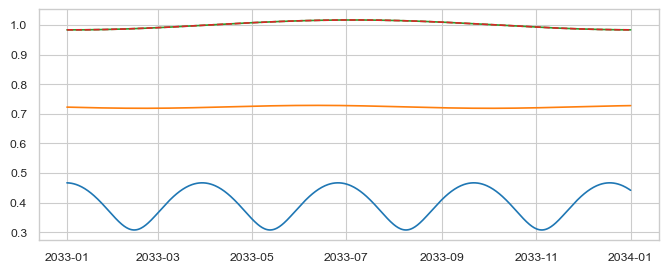

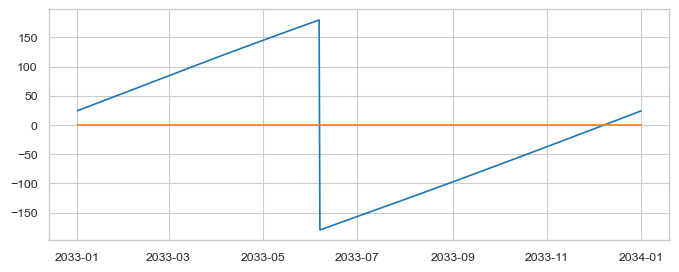

In [18]:
#check if de442.bsp is available, otherwise download

def download_if_not_exist(url, filepath):
    if os.path.exists(filepath):
        print(f"File already exists at {filepath}")
        return filepath
    
    # Create directory if needed
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    
    # Download
    response = requests.get(url)
    response.raise_for_status()
    
    with open(filepath, 'wb') as f:
        f.write(response.content)
    
    print(f"Downloaded to {filepath}")
    return filepath


filepath='kernels/de442.bsp'
url='https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de442.bsp'

download_if_not_exist(url,filepath)

#use two arbitray years for the planets
start=datetime.datetime(2033,1,1)
end=datetime.datetime(2034,1,1)

times = [] 
dt=12 #time resolution for planets is 1 day
# Generate datetimes with increments of dt hours until the end date
current = start
while current <= end:
    times.append(current)
    current += datetime.timedelta(hours=dt)
    

def cart2sphere_rad(x,y,z):
    
    r = np.sqrt(x**2+ y**2 + z**2) / au
    theta = np.arctan2(z,np.sqrt(x**2+ y**2)) * 360 / 2 / np.pi
    phi = np.arctan2(y,x) * 360 / 2 / np.pi    
    
    theta=np.deg2rad(theta)
    phi=np.deg2rad(phi)
    
    return (r, theta, phi)

def generic_furnish(kernels_path):
    generic_path = kernels_path
    generic_kernels = os.listdir(generic_path)
    print(generic_kernels)    
    #spiceypy.furnsh(os.path.join(generic_path, 'de442.bsp'))
        
    for kernel in generic_kernels:
        spiceypy.furnsh(os.path.join(generic_path, kernel))
        
def get_planet_pos(t,kernels_path, planet):
    if spiceypy.ktotal('ALL') < 1:
        generic_furnish(kernels_path)
    pos = spiceypy.spkpos(planet, spiceypy.datetime2et(t), "HEEQ", "NONE", "SUN")[0]
    r, lat, lon = cart2sphere_rad(pos[0],pos[1],pos[2])
    position = t, pos[0], pos[1], pos[2], r, lat, lon
    return position


def get_planet_positions(time_series,kernels_path,planet):
    positions = []
    for t in time_series:
        position = get_planet_pos(t,kernels_path, planet)
        positions.append(position)
    df_positions = pd.DataFrame(positions, columns=['time', 'x', 'y', 'z', 'r', 'lat', 'lon'])
    return df_positions



def get_planet_pos_hci(t,kernels_path, planet):
    if spiceypy.ktotal('ALL') < 1:
        generic_furnish(kernels_path)
    pos = spiceypy.spkpos(planet, spiceypy.datetime2et(t), "HCI", "NONE", "SUN")[0]
    r, lat, lon = cart2sphere_rad(pos[0],pos[1],pos[2])
    position = t, pos[0], pos[1], pos[2], r, lat, lon
    return position


def get_planet_positions_hci(time_series,kernels_path,planet):
    positions = []
    for t in time_series:
        position = get_planet_pos_hci(t,kernels_path, planet)
        positions.append(position)
    df_positions = pd.DataFrame(positions, columns=['time', 'x', 'y', 'z', 'r', 'lat', 'lon'])
    return df_positions





# make Earth Mercury and Venus positions
generic_furnish(kernels_path)    
print(kernels_path)
mercury=get_planet_positions(times,kernels_path, 'MERCURY_BARYCENTER')
venus=get_planet_positions(times,kernels_path, 'VENUS_BARYCENTER')
earth=get_planet_positions(times,kernels_path, 'EARTH_BARYCENTER')

earth_hci=get_planet_positions_hci(times,kernels_path, 'EARTH_BARYCENTER')



#to matplotlib datenumber
#mercury.time=mdates.date2num(mercury.time)
#venus.time=mdates.date2num(venus.time)
#earth.time=mdates.date2num(earth.time)


sns.set_style('whitegrid')
sns.set_context('paper')   
# Create the plot
fig, ax = plt.subplots(figsize=(8, 3),dpi=100)
plt.plot(mercury.time,mercury.r,'-')
plt.plot(venus.time,venus.r,'-')
plt.plot(earth.time,earth.r,'-')
plt.plot(earth_hci.time,earth_hci.r,'--')

fig, ax = plt.subplots(figsize=(8, 3),dpi=100)
plt.plot(earth_hci.time,np.rad2deg(earth_hci.lon))
plt.plot(earth.time,np.rad2deg(earth.lon))


## Read DRO files 
produced by dro.ipynb, here the 2 year file is used as its easier for the animations to make 1 orbital period with 2 years for the spacecraft positions

In [20]:
file_dir='orbit_files/'
filename_pickle='dro_all_2years.p'

with open(file_dir+filename_pickle, 'rb') as f:
        orbits_polar= pickle.load(f)
        orbits_cart = pickle.load(f)

## Animation frames for Figure 2 (HEE visualization)

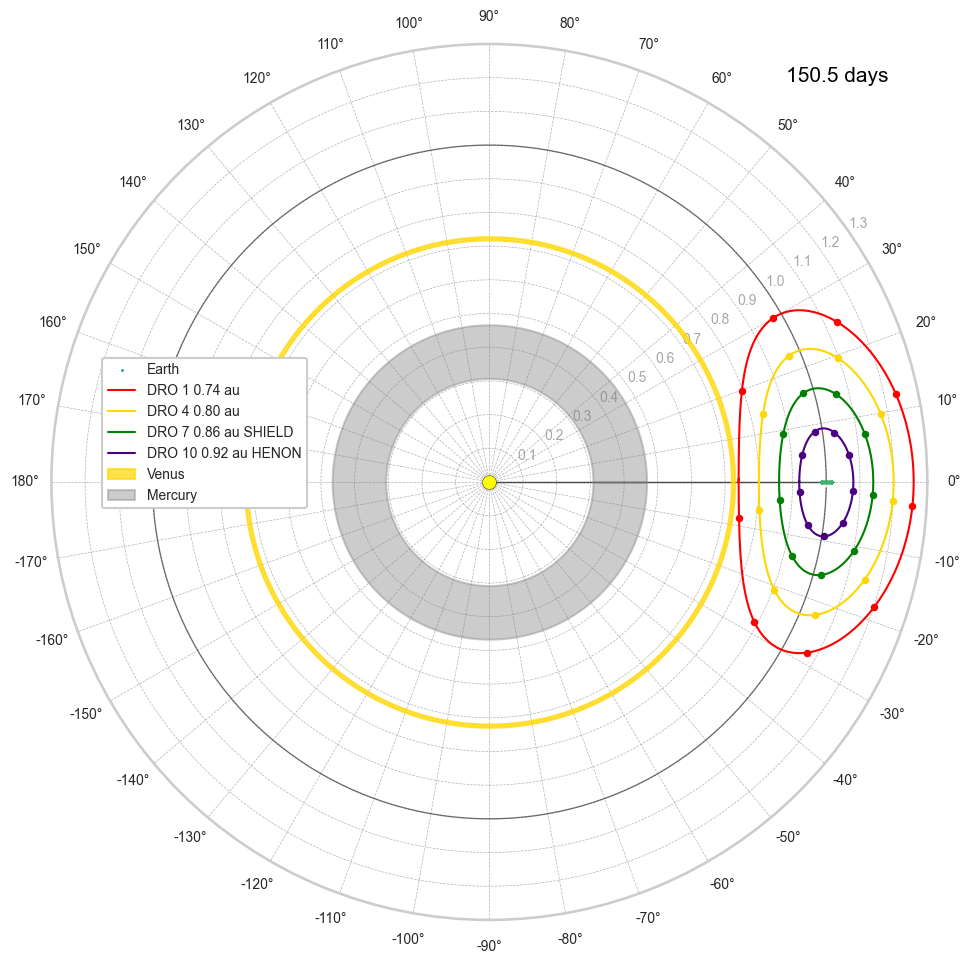

In [21]:
sns.set_style('whitegrid')
sns.set_context('talk')    

dro_colors = [
    'red',
    'orangered',
    'orange',
    'gold',
    'yellow',
    'yellowgreen',
    'green',
    'teal',
    'blue',
    'indigo',
    'violet'
]



def make_frame(i):

    fig, ax = plt.subplots(1,figsize=(10,10),subplot_kw={'projection': 'polar'},dpi=100)    
    
    #ax.text(0,0,'Sun', color='black', ha='center',fontsize=fsize-5,verticalalignment='top')
    #ax.text(0,1.2,'Earth', color='mediumseagreen', ha='center',fontsize=fsize-5,verticalalignment='center')
    symsize_planet=5
    # Sun
    ax.scatter(0,0,s=100,c='yellow',alpha=1, edgecolors='black', linewidth=0.3)
    ax.scatter(earth.lon, earth.r, s=symsize_planet, c='mediumseagreen', alpha=1,lw=0,zorder=3,marker=None, label='Earth')  
    
    #Sun-Earth line
    ax.plot(np.zeros(11),np.arange(0,1.1,0.1),c='k',lw=1,alpha=0.8,linestyle='-',zorder=0)
    
    #1 au circle
    ax.plot(np.deg2rad(np.arange(0,360)),np.zeros(360)+1,lw=1,alpha=0.5,linestyle='-',c='black', marker=None)
    


    #plot the line only for the first year
    ax.plot(orbits_polar[1,0:8784,0], orbits_polar[0,0:8784,0], dro_colors[0], linewidth=1.5, alpha=1.0, label='DRO 1 0.74 au')
    ax.plot(orbits_polar[1,0:8784,3], orbits_polar[0,0:8784,3], dro_colors[3], linewidth=1.5, alpha=1.0, label='DRO 4 0.80 au')
    ax.plot(orbits_polar[1,0:8784,6], orbits_polar[0,0:8784,6], dro_colors[6], linewidth=1.5, alpha=1.0, label='DRO 7 0.86 au SHIELD')
    ax.plot(orbits_polar[1,0:8784,9], orbits_polar[0,0:8784,9], dro_colors[9], linewidth=1.5, alpha=1.0, label='DRO 10 0.92 au HENON')
    
    # grid line appearance
    ax.grid(True, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
    
    #shaded areas for planets
    inner_venus=0.718440 
    outer_venus=0.728213
    theta = np.linspace(0, 2 * np.pi, 200)
    r_inner = np.full_like(theta, inner_venus)
    r_outer = np.full_like(theta, outer_venus)
    ax.fill_between(theta, r_inner, r_outer, color='gold', alpha=0.7, label='Venus')
    
    inner_mercury=   0.307499      
    outer_mercury= 0.466697          
    r_inner = np.full_like(theta, inner_mercury)
    r_outer = np.full_like(theta, outer_mercury)
    ax.fill_between(theta, r_inner, r_outer, color='grey', alpha=0.4, label='Mercury')
           
    fsize=15
    #set axes
    ax.set_theta_zero_location('E')
    plt.rgrids((0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.6,2.0,2.5),('0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8','0.9','1.0','1.1','1.2','1.3','1.6 AU','2.0','2.5'),angle=35, fontsize=fsize-5,alpha=0.4)
    
    degrees = np.arange(0, 360, 10)
    ax.set_xticks(np.radians(degrees))
    
    deg_label = np.concatenate([np.arange(0, 190, 10), np.arange(-170,0,10)])
    ax.set_xticklabels([f'{d}°' for d in deg_label], fontsize=10)
    #ax.legend(bbox_to_anchor=(0.95, 1.03), loc='upper left',fontsize=10)
    ax.legend(bbox_to_anchor=(0.05, 0.65), loc='upper left',fontsize=10, framealpha=1.0)
    ax.set_ylim(0, 1.3) 
    
    ################### plot spacecraft


    time_resolution=12 ###### set time resolution here in hours
    
    #number of SHIELD spacecraft nr_sc from global variable
    array_size=int(orbits_polar.shape[1]/2)  # all time datapoints for a 2 year file, divide by half
    interval=int(np.round(array_size/nr_sc)) #round to nearest hour
    
    #indices of shield spacecraft equidistant in time over 1 year
    shield_i=np.arange(0,array_size,interval)[0:nr_sc]+i*time_resolution
    #print(shield_i)
    
    #print('Number of SHIELD Spacecraft:',nr_sc)
    #print('Interval in days:',interval/24)
    #print('longitudes:',np.round(np.rad2deg(orbits_polar[1,shield_i,0])))
    
    ax.scatter(orbits_polar[1,shield_i,0], orbits_polar[0,shield_i,0],marker='o', c=dro_colors[0], alpha=1.0,s=15)
    ax.scatter(orbits_polar[1,shield_i,3], orbits_polar[0,shield_i,3],marker='o', c=dro_colors[3], alpha=1.0,s=15)
    ax.scatter(orbits_polar[1,shield_i,6], orbits_polar[0,shield_i,6],marker='o', c=dro_colors[6], alpha=1.0,s=15)
    ax.scatter(orbits_polar[1,shield_i,9], orbits_polar[0,shield_i,9],marker='o', c=dro_colors[9], alpha=1.0,s=15)
    
    plt.tight_layout()

    plt.figtext(0.8,0.9,str(i*time_resolution/24)+' days', color='black', ha='left',fontsize=fsize)

    #print(fig.get_size_inches()*200) #2000 x 2000 size
    plt.savefig(f'results/frames_fig2_anim/dro{i:04d}.jpg', dpi=200,bbox_inches='tight')


    ##########******** show frames without plt.close() first
    #plt.close()


#up to 75 spacecraft possible
nr_sc=9
make_frame(301)

## Make animation for Figure 2 (HEE)

In [22]:
#don't forget to add plt.close() above when making the animation

def make_animation():

    print()
    print('make animation')
    print('number of spacecraft', nr_sc)
        
    ffmpeg_path=''
    outputdirectory = 'results/frames_fig2_anim/'
    animdirectory   = 'results/'
    movie_filename=f'dro_hee_{nr_sc}'
    
    
    factor=12
    i_all=int(366*24/factor) #365*24 for all frames for 1 year, 1 hour resolution, divided by factor
    counter=[i for i in range(i_all)]
    
    print('number of frames',i_all)
    
    used=8
    print('Using multiprocessing, nr of cores',mp.cpu_count(), \
          'with nr of processes used: ',used)
    
    #define pool using fork and number of processes
    pool=mp.get_context('fork').Pool(processes=used)
    # Map the worker function onto the parameters    
    t0 = time.time()
    pool.map(make_frame, counter) #or use apply_async?,imap
    pool.close()
    pool.join()     
    t1 = time.time()
    
    
    print('time in sec: ',np.round((t1-t0),1))
    print('plots done, frames saved in ',outputdirectory)


    os.system(ffmpeg_path+'ffmpeg -r 30 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
         '+str(animdirectory)+'/'+movie_filename+'.mp4 -y -loglevel quiet')    
    print('movie done, saved in ',animdirectory)


    #### -b:v 2500k smaller filesize if needed

    os.system(ffmpeg_path+'ffmpeg -r 30 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 2500k \
         '+str(animdirectory)+'/'+movie_filename+'_small.mp4 -y -loglevel quiet')    
    print('movie done, saved in ',animdirectory)
    
    
    os.system(ffmpeg_path+'ffmpeg -r 30 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
         '+str(animdirectory)+'/'+movie_filename+'.gif -y -loglevel quiet')    



################### FOR MAKING an animation, set the number of spacecraft nr_sc and then call the make_animation function

#nr_sc=40;make_animation()



#make all animations with nr of spacecraft as needed

#nr_sc this is a global variable also used in make_frame
#nr_sc=6;make_animation()
#nr_sc=7;make_animation()
#nr_sc=8;make_animation()
#nr_sc=9;make_animation()
#nr_sc=10;make_animation()
#nr_sc=11;make_animation()
#nr_sc=12;make_animation()

#nr_sc=15;make_animation()

#nr_sc=20;make_animation()

#nr_sc=40;make_animation()



## Animations in the HCI coordinate system
for visuals for talks
method: just add Earth longitude to all dro spacecraft

In [23]:
start=datetime.datetime(2033,1,1)
end=datetime.datetime(2034,12,31,23)

times = [] 
dt=1 #time resolution is 1 hour is similar to DROs
# Generate datetimes with increments of dt hours until the end date
current = start
while current <= end:
    times.append(current)
    current += datetime.timedelta(hours=dt)
    
earth_hci=get_planet_positions_hci(times,kernels_path, 'EARTH_BARYCENTER')

#set initial longitude to 0
earth_hci.lon=earth_hci.lon-earth_hci.lon[0]


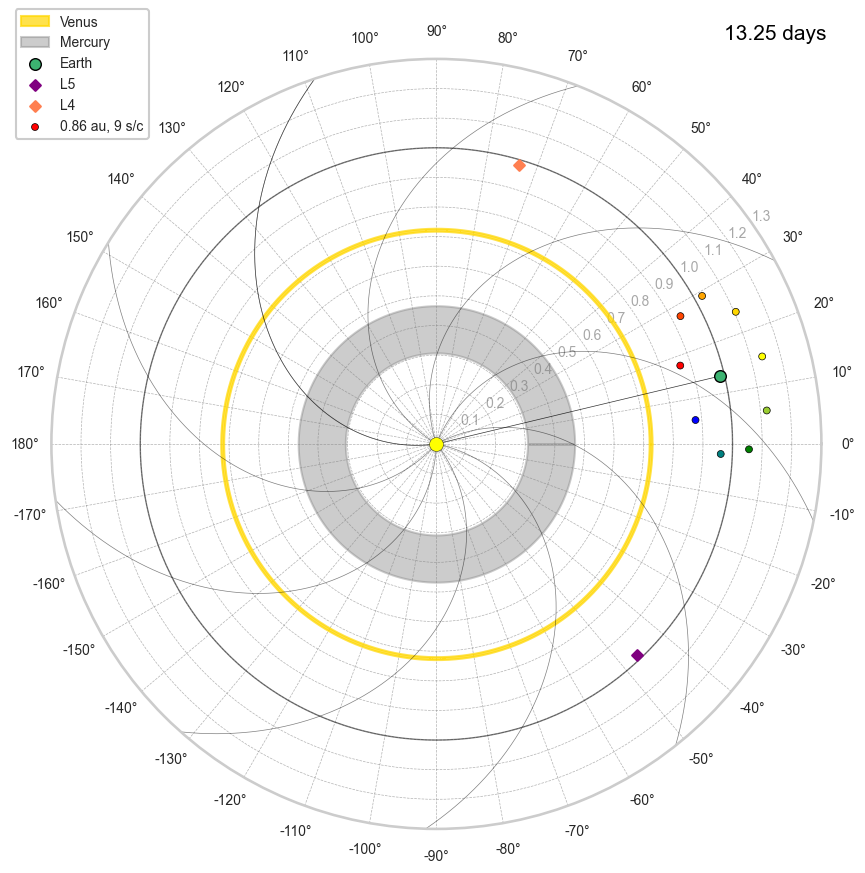

In [25]:
sns.set_style('whitegrid')
sns.set_context('talk')    

dro_colors = [
    'red',
    'orangered',
    'orange',
    'gold',
    'yellow',
    'yellowgreen',
    'green',
    'teal',
    'blue',
    'indigo',
    'violet'
]

#set here the time resolution, used in both functions
factor=3


def make_frame_hci(i):

    fig, ax = plt.subplots(1,figsize=(10,10),subplot_kw={'projection': 'polar'},dpi=100)    
    
    symsize_planet=5
    fsize=15
        
    # Sun
    ax.scatter(0,0,s=100,c='yellow',alpha=1, edgecolors='black', linewidth=0.3,zorder=3)
    
    #1 au circle
    ax.plot(np.deg2rad(np.arange(0,361)),np.zeros(361)+1,lw=1,alpha=0.5,linestyle='-',c='black', marker=None)
    
    # grid line appearance
    ax.grid(True, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
    
    # shaded areas for planets
    
    # Venus
    inner_venus=0.718440 
    outer_venus=0.728213
    theta = np.linspace(0, 2 * np.pi, 200)
    r_inner = np.full_like(theta, inner_venus)
    r_outer = np.full_like(theta, outer_venus)
    ax.fill_between(theta, r_inner, r_outer, color='gold', alpha=0.7, label='Venus')

    # Mercury
    inner_mercury=   0.307499      
    outer_mercury= 0.466697          
    r_inner = np.full_like(theta, inner_mercury)
    r_outer = np.full_like(theta, outer_mercury)
    ax.fill_between(theta, r_inner, r_outer, color='grey', alpha=0.4, label='Mercury')
           
    # set axes
    ax.set_theta_zero_location('E')
    plt.rgrids((0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.6,2.0,2.5),('0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8','0.9','1.0','1.1','1.2','1.3','1.6 AU','2.0','2.5'),angle=35, fontsize=fsize-5,alpha=0.4)
    degrees = np.arange(0, 360, 10)
    ax.set_xticks(np.radians(degrees))    
    deg_label = np.concatenate([np.arange(0, 190, 10), np.arange(-170,0,10)])
    ax.set_xticklabels([f'{d}°' for d in deg_label], fontsize=10)
    ax.set_ylim(0, 1.3) 
    
    time_resolution=factor #global variable for time resolution in hours
    
    #nr_sc ->number of SHIELD spacecraft nr_sc from global variable
    array_size=int(orbits_polar.shape[1]/2)  # all time datapoints for a 2 year file, divide by half
    interval=int(np.round(array_size/nr_sc)) #round to nearest hour
    
    #indices of shield spacecraft equidistant in time over 1 year
    shield_i=np.arange(0,array_size,interval)[0:nr_sc]+i*time_resolution
        
    
    #Sun-Earth line
    ax.plot([0,earth_hci.lon[shield_i[0]]],[0 , earth_hci.r[shield_i[0]] ],lw=0.5,c='k',alpha=0.8 )

    # value to add Earth longitude to SHIELD fleet
    add_longitude=earth_hci.lon[shield_i[0]]
    #print(add_longitude)

    # Earth position
    ax.scatter(earth_hci.lon[shield_i[0]], earth_hci.r[shield_i[0]], s=70, edgecolor='k', facecolor='mediumseagreen',lw=1,alpha=1,zorder=3, label='Earth')  

    #L5
    ax.scatter(earth_hci.lon[shield_i[0]]-np.deg2rad(60), earth_hci.r[shield_i[0]], s=30, marker='D', facecolor='purple',alpha=1,zorder=3, label='L5')  

    #L4
    ax.scatter(earth_hci.lon[shield_i[0]]+np.deg2rad(60), earth_hci.r[shield_i[0]], s=30, marker='D', facecolor='coral',alpha=1,zorder=3, label='L4')  

    
    ################### plot spacecraft

    #ORBIT 6 is defined here in the array - this is the 0.86 au one
     
    ax.scatter(orbits_polar[1,shield_i,6]+add_longitude, orbits_polar[0,shield_i,6],marker='o', edgecolor='k', facecolor=dro_colors[0:9],s=25, label='0.86 au, 9 s/c', lw=0.5)#,edgecolor='black')
    
    #ax.scatter(orbits_polar[1,shield_i,9], orbits_polar[0,shield_i,9],marker='o', c=dro_colors[9], alpha=1.0,s=15)
    #ax.scatter(orbits_polar[1,shield_i,0], orbits_polar[0,shield_i,0],marker='o', c=dro_colors[0], alpha=1.0,s=15)
    #ax.scatter(orbits_polar[1,shield_i,3], orbits_polar[0,shield_i,3],marker='o', c=dro_colors[3], alpha=1.0,s=15)

    plt.figtext(0.8,0.9,str(f"{np.round(i*time_resolution/24,2):.2f}")+' days', color='black', ha='left',fontsize=fsize)
    #plt.figtext(0.8,0.85,str(np.round(i*time_resolution,2))+' hours', color='black', ha='left',fontsize=fsize)

    ######### plot parker spiral
    omega_sun = 2 * np.pi / (25.38 * 86400)    # solar rotation rate (rad/s), sidereal ~25.4 days
    r_sun = 6.96e8                             # solar radius (m)
    r0 = 1 * r_sun                             # inner boundary (source surface), ~10 R_sun
    r_max = 1.5 * 1.496e11                     # out to 5 AU
    AU = 1.496e11
        
    r = np.linspace(r0, r_max, 500)
    #time dependence
    phi0_time_offset=i*time_resolution*3600*omega_sun  #i*time_resolution is hours, convert to minutes, times solar rotation
    
    for phi0 in np.linspace(0,2*np.pi,10):
        phi = phi0 - (omega_sun / 400e3) * (r - r0)+phi0_time_offset
        plt.plot(phi, r / AU, linewidth=0.5,c='k',alpha=0.5)

    ax.legend(loc='center',bbox_to_anchor=(0.04, 0.98), fontsize=10, framealpha=1.0)
        
    #print(fig.get_size_inches()*200) #2000 x 2000 size
    plt.savefig(f'results/frames_hci/dro{i:04d}.jpg', dpi=200)

    ########## show frames without plt.close() first
    #plt.close()

#up to 75 spacecraft possible
nr_sc=9
make_frame_hci(106)

## Make animation

In [16]:

#don't forget to add plt.close() above when making the animation

def make_animation_hci():

    print()
    print('make animation')
    print('number of spacecraft', nr_sc)
        
    ffmpeg_path=''
    outputdirectory = 'results/frames_hci/'
    animdirectory   = 'results/hci_movies'
    movie_filename=f'dro_hci_{nr_sc}'
        
    i_all=int(366*24/factor) #366*24 for all frames for 1 year, 1 hour resolution, divided by factor
    #i_all=10 #for testing
    counter=[i for i in range(i_all)]
    
    print('number of frames',i_all)
    
    used=8
    print('Using multiprocessing, nr of cores',mp.cpu_count(), \
          'with nr of processes used: ',used)
    
    #define pool using fork and number of processes
    pool=mp.get_context('fork').Pool(processes=used)
    # Map the worker function onto the parameters    
    t0 = time.time()
    pool.map(make_frame_hci, counter) #or use apply_async?,imap
    pool.close()
    pool.join()     
    t1 = time.time()
    
    
    print('time in minutes: ',np.round((t1-t0)/60,1))
    print('plots done, frames saved in ',outputdirectory)


    os.system(ffmpeg_path+'ffmpeg -r 25 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
         '+str(animdirectory)+'/'+movie_filename+'.mp4 -y -loglevel quiet')    
    print('movie done, saved in ',animdirectory)


    #### -b:v 2500k smaller filesize if needed

    #os.system(ffmpeg_path+'ffmpeg -r 30 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 2500k \
    #     '+str(animdirectory)+'/'+movie_filename+'_small.mp4 -y -loglevel quiet')    
    #print('movie done, saved in ',animdirectory)
    
    
    #os.system(ffmpeg_path+'ffmpeg -r 25 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
    #     '+str(animdirectory)+'/'+movie_filename+'.gif -y -loglevel quiet')    



################### FOR MAKING an animation, set the number of spacecraft nr_sc and then call the make_animation function



#1 for SHIELD
nr_sc=9;make_animation_hci()


#1 for HENON - set orbit
#nr_sc=1;make_animation_hci()



#nr_sc=40;make_animation()



#make all animations with nr of spacecraft as needed

#nr_sc this is a global variable also used in make_frame
#nr_sc=6;make_animation()
#nr_sc=7;make_animation()
#nr_sc=8;make_animation()
#nr_sc=10;make_animation()
#nr_sc=11;make_animation()
#nr_sc=12;make_animation()

#nr_sc=15;make_animation()

#nr_sc=20;make_animation()

#nr_sc=40;make_animation()




make animation
number of spacecraft 9
number of frames 2928
Using multiprocessing, nr of cores 8 with nr of processes used:  8
time in minutes:  5.2
plots done, frames saved in  results/frames_hci/
movie done, saved in  results/hci_movies
